# Examining multi-objective NSGA results

This notebook presents the analysis for multi-objective experiments.

Due to computational and time constraints, only few runs were performed, each using small population size and limited generation count. Consequently, optimisation was very noisy.

Because of this, fine-grained evaluations of convergence, diversity and population migration in objective space were not considered reliable and were not reported. Instead, the analysis focussed on two metrics that, even in this small-scale and noisy setting, remained informative.

These were: 1. average population accuracy over generations; 2. average population convergence over generations.

In [1]:
import json
import numpy as np
import pandas as pd
from scipy import stats
from matplotlib import pyplot as plt

Load experimental data. Check experimental details and first run.

In [2]:
file = open("./whole/tests/NSGA/mnist/noAE/checkpoint_6.json", "r")
checkpoint = json.load(file)
print(type(checkpoint))

results = checkpoint["results"]
runs = results[1:]
print(results[0]) # basic experiment 
print(results[1])

<class 'dict'>
{'dataset': 'mnist', 'pop_size': 60, 'bound_runs': 5, 'bound_gens': 5, 'evo_runs': 31, 'evo_gens': 50, 'prestep': False, 'interval': [1, 5], 'seed': 34}
{'test_fit_1': 0.1412055555555555, 'test_fit_2': 2.0594286205509897, 'val_fits': [0.11091909028844511, 0.11519192268305176, 0.11806587728281273, 0.11840723587642937, 0.12119010112647206, 0.13429423493770268, 0.12633681472947603, 0.13198840032428744, 0.13334184843830008, 0.1352421266427718, 0.11673782727427891, 0.13243887736815155, 0.13185680235535077, 0.1303091790407919, 0.13180293608124247, 0.12864736473800986, 0.13467512800819248, 0.13481956946577914, 0.1295248301757979, 0.13325763867554188, 0.1360786328725038, 0.13390190390851672, 0.13497063108038906, 0.133639657791432, 0.1352538048301758, 0.1313438658474142, 0.13503925541901343, 0.13077170634920637, 0.1444484941969619, 0.1444180282471411, 0.14016202508960568, 0.14085705709165378, 0.140296198583376, 0.14624012416794674, 0.14442523596176818, 0.1408446104284007, 0.15063

Define helper functions to easily extract data from results.

In [3]:
def fetch_dv(results:dict, what:str):
    """return either list if what="fit_in_time" or int if what="test_fit" """
    return results[what] # results.get(what)


def gen_avg(lista: list[list]):
    generations = zip(*lista)
    avgs = [sum(gen)/len(gen) for gen in generations]
    return avgs

Extract accuracy and convergence trajectories.

In [4]:
curves = [fetch_dv(run, "val_fits") for run in runs]
print(curves)
print(len(curves)) # 6 curves, one for experimental run 
avgs = gen_avg(curves)

convergences = [fetch_dv(run, "conv") for run in runs]
print(convergences)
print(len(convergences)) # 6 curves, one for experimental run 
avg_conv = gen_avg(convergences)

[[0.11091909028844511, 0.11519192268305176, 0.11806587728281273, 0.11840723587642937, 0.12119010112647206, 0.13429423493770268, 0.12633681472947603, 0.13198840032428744, 0.13334184843830008, 0.1352421266427718, 0.11673782727427891, 0.13243887736815155, 0.13185680235535077, 0.1303091790407919, 0.13180293608124247, 0.12864736473800986, 0.13467512800819248, 0.13481956946577914, 0.1295248301757979, 0.13325763867554188, 0.1360786328725038, 0.13390190390851672, 0.13497063108038906, 0.133639657791432, 0.1352538048301758, 0.1313438658474142, 0.13503925541901343, 0.13077170634920637, 0.1444484941969619, 0.1444180282471411, 0.14016202508960568, 0.14085705709165378, 0.140296198583376, 0.14624012416794674, 0.14442523596176818, 0.1408446104284007, 0.15063348864994022, 0.14666235321727253, 0.1456527952722307, 0.14732959762758152, 0.14714290919952203, 0.14982395203959717, 0.15069969875405353, 0.14947123357228193, 0.1477710552142004, 0.14650949948796718, 0.14581003626898786, 0.1399837391193036, 0.1411

Plot accuracy over generation for each experimental run.

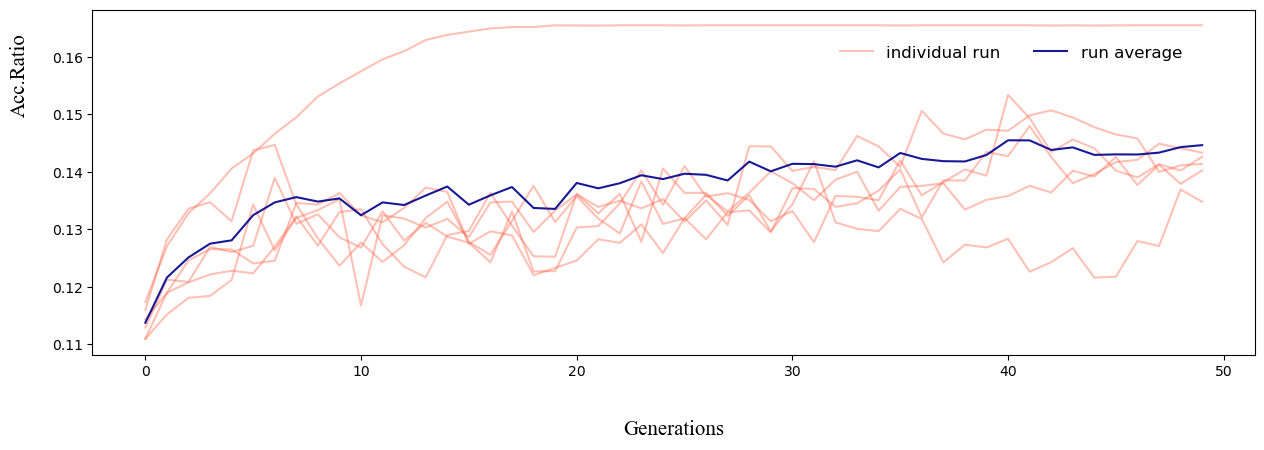

In [ ]:
from matplotlib.lines import Line2D


fig, ax = plt.subplots(figsize =(15, 5))

for i, curve in enumerate(curves):
    ax.plot(curve, alpha=0.4, color="tomato", label="individual run" if i==0 else None)

ax.plot(avgs, alpha=0.9, color="darkblue", label="run average")
ax.set_xlabel("Generations", fontname="Times New Roman", fontsize=15, labelpad=30)

ax.legend(
    loc="upper right",
    ncol=2, fontsize=12,
    frameon=False,
    bbox_to_anchor=(0.95, 0.94))

fig.supylabel("Acc.Ratio", fontsize=15, fontname="Times New Roman", y=0.67, x=0.07)
# fig.suptitle("Avg. Accuracy in Time", fontsize=30, fontname="times New Roman")
fig.subplots_adjust(top=0.8, hspace=0.4, wspace=0.3)

# fig.savefig("./whole/tests/NSGA/mnist/noAE/acc_in_time.png", dpi=300, bbox_inches="tight")

Plot convergence trajectories over generations for each experimental run.

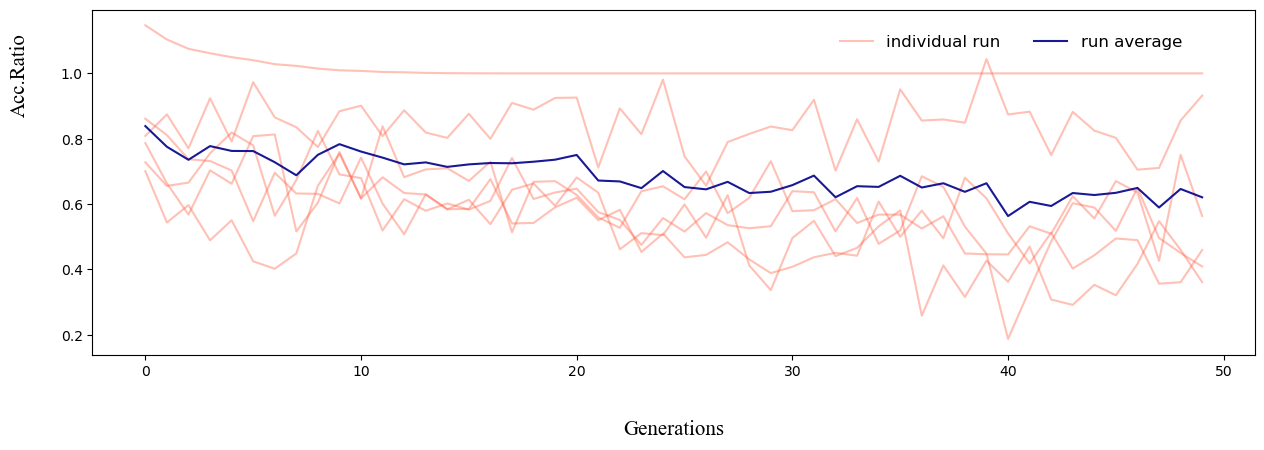

In [ ]:
from matplotlib.lines import Line2D


fig, ax = plt.subplots(figsize =(15, 5))

for i, conv in enumerate(convergences):
    ax.plot(conv, alpha=0.4, color="tomato", label="individual run" if i==0 else None)

ax.plot(avg_conv, alpha=0.9, color="darkblue", label="run average")
ax.set_xlabel("Generations", fontname="Times New Roman", fontsize=15, labelpad=30)

ax.legend(
    loc="upper right",
    ncol=2, fontsize=12,
    frameon=False,
    bbox_to_anchor=(0.95, 0.97))

fig.supylabel("Acc.Ratio", fontsize=15, fontname="Times New Roman", y=0.67, x=0.07)
# fig.suptitle("Avg. Accuracy in Time", fontsize=30, fontname="times New Roman")
fig.subplots_adjust(top=0.8, hspace=0.4, wspace=0.3)

# fig.savefig("./whole/tests/NSGA/mnist/noAE/conv_in_time.png", dpi=300, bbox_inches="tight")